<a href="https://colab.research.google.com/github/inhyuk78/pharmacokinetics-modelling/blob/main/two_compartment_IV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Part 2: Two-Compartment IV Bolus - Weighted Fitting**

**Two-Compartment Model:** Extends the one-compartment model by introducing a peripheral compartment representing less-perfused tissues, eg. muscle and adipose tissue, alongside the central compartment (blood and highly perfused organs, eg. liver, heart, kidneys). The drug distributes bidirectionally between the two compartments while elimination occurs from the central compartment.

The concentration–time curve exhibits two phases:

1.   **Distribution phase (α):** An initial steep decline in central-compartment drug concentration, driven primarily by distribution from the central to the peripheral compartment, alongside ongoing elimination. The rate of decline is characterised by the distribution rate constant (α).
2.   **Elimination phase (β):** A later, shallower decline after distributional effects have diminished. Although drug continues to exchange between compartments, their concentrations decline according to the terminal elimination phase. The rate of decline is characterised by the terminal rate constant (β).

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

**2.0 Baseline Parameters**

In [41]:
# ----- Baseline parameters -----
D_fixed = 1000.0                # dose, mg
Vd_fixed = 50.0                 # volume of distribution, L
k10_fixed = 0.20                # elimination rate constant, 1/hr (central -> elimination)
k12_fixed = 0.10                # distribution rate constant, 1/hr (central -> peripheral)
k21_fixed = 0.05                # redistribution rate constant, 1/hr (peripheral -> central)
C0_fixed = D_fixed / Vd_fixed   # initial concentration, mg/L

**2.1 Baseline Model**

In [42]:
def macro_constants(k10, k12, k21):
    '''Eigenvalues of the two-compartment system: alpha (fast) > beta (slow).'''
    sum_k = k10 + k12 + k21
    disc = sum_k**2 - 4 * k10 * k21          # > 0 whenever k12 > 0
    a = (sum_k + np.sqrt(disc)) / 2
    b = (sum_k - np.sqrt(disc)) / 2
    return a, b

def two_compartment(t, D, Vd, k10, k12, k21):
    '''Biexponential solution. Returns (C_fast, C_slow, C_total).'''
    C0 = D / Vd
    a, b = macro_constants(k10, k12, k21)
    C_fast = C0 * (k12 + k10 - b) * np.exp(-a * t) / (a - b)
    C_slow = C0 * (a - k12 - k10) * np.exp(-b * t) / (a - b)
    C_total = C_fast + C_slow
    return C_fast, C_slow, C_total

def fit_func(t, C0, k10, k12, k21):
  'Fitting wrapper: fit C0 directly, since D and Vd are not separately identifiable.'
  return two_compartment(t, C0, 1.0, k10, k12, k21)[2]

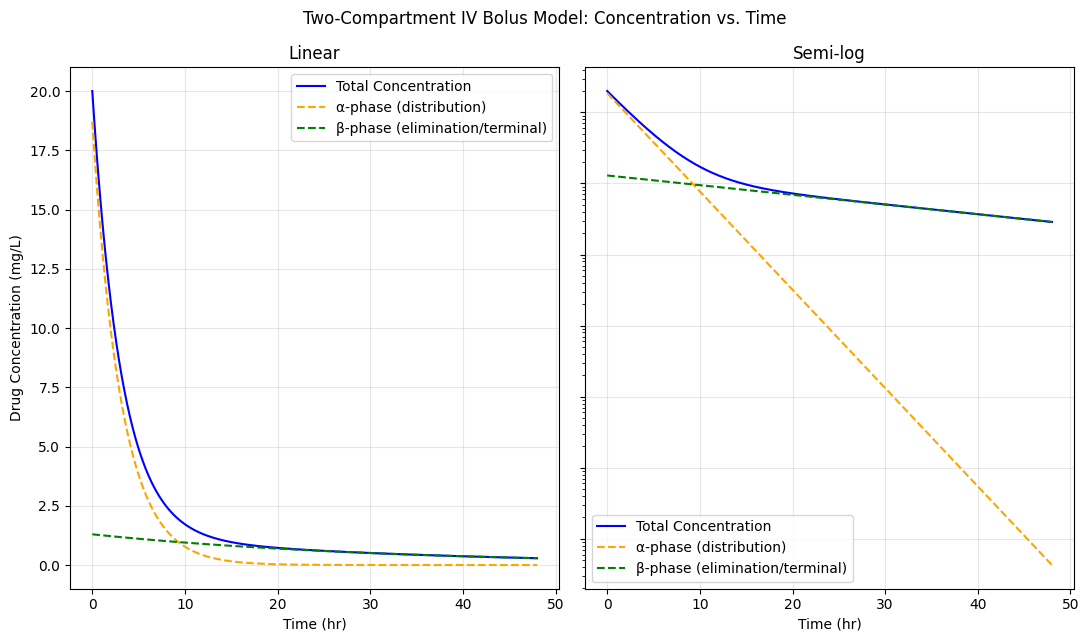

In [43]:
t = np.linspace(0, 48, 500)  # 0 to 48 hours
C_fast, C_slow, C_total = two_compartment(t, D_fixed, Vd_fixed, k10_fixed, k12_fixed, k21_fixed)

fig, axs = plt.subplots(1, 2, figsize=(11,6.5))
fig.suptitle('Two-Compartment IV Bolus Model: Concentration vs. Time')

axs[0].plot(t, C_total, linestyle='solid', color='blue', label='Total Concentration')
axs[0].plot(t, C_fast, linestyle='dashed', color='orange', label='α-phase (distribution)')
axs[0].plot(t, C_slow, linestyle='dashed', color='green', label='β-phase (elimination/terminal)')
axs[0].legend(loc='upper right')
axs[0].set_title('Linear')

axs[1].plot(t, C_total, linestyle='solid', color='blue', label='Total Concentration')
axs[1].plot(t, C_fast, linestyle='dashed', color='orange', label='α-phase (distribution)')
axs[1].plot(t, C_slow, linestyle='dashed', color='green', label='β-phase (elimination/terminal)')
axs[1].legend(loc='lower left')
axs[1].set_yscale('log')
axs[1].set_title('Semi-log')

for ax in axs:
  ax.set(xlabel='Time (hr)', ylabel='Drug Concentration (mg/L)')
  ax.grid(True, alpha=0.3)
  ax.label_outer()

plt.tight_layout()
plt.show()

**2.2 Sensitivity Analysis: Effect of k and dose**

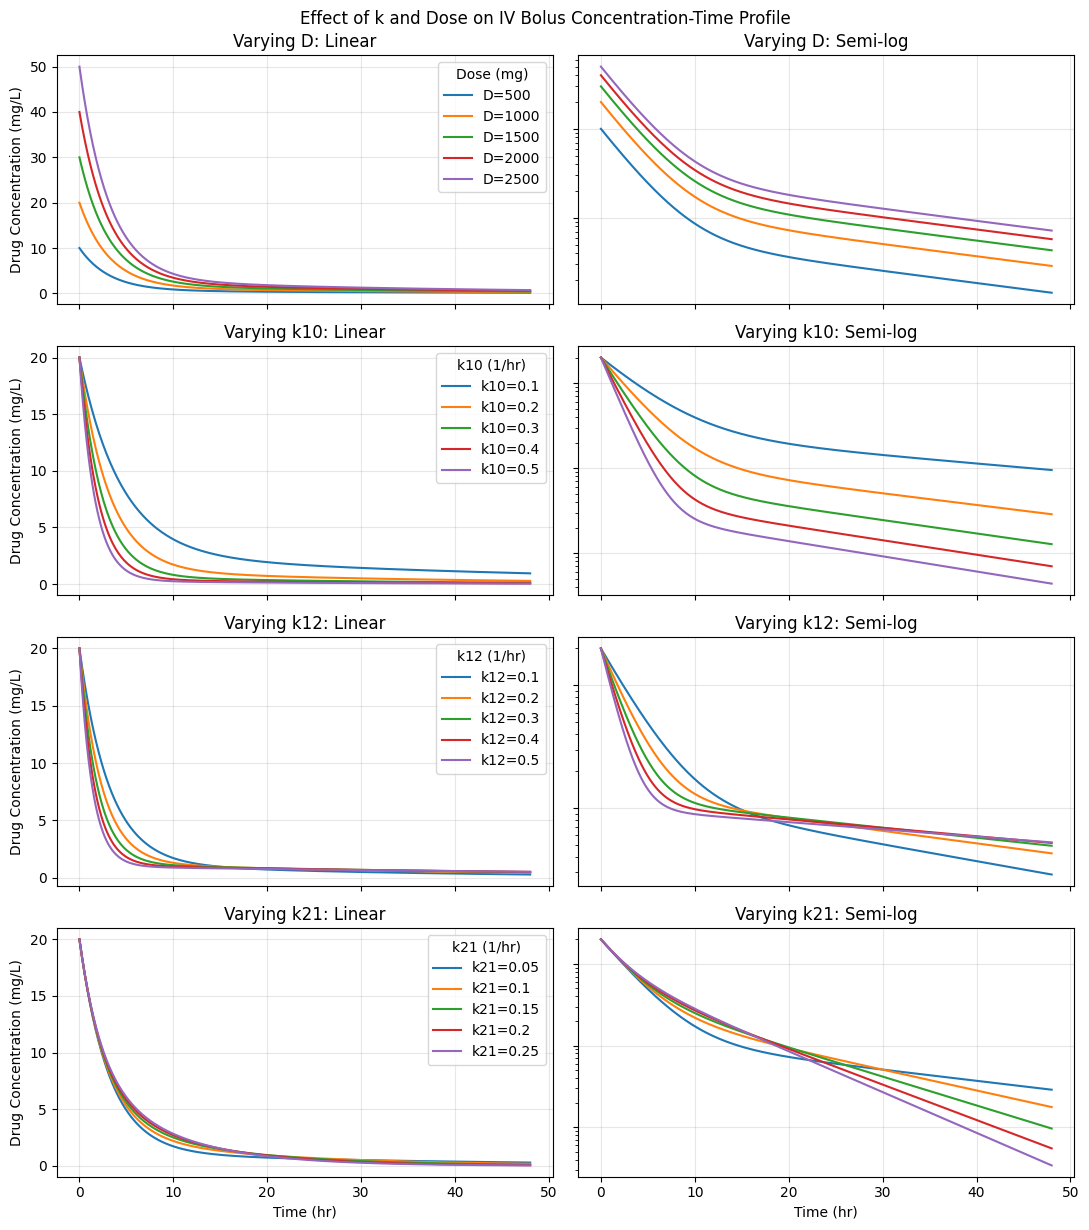

In [44]:
D_values = [500, 1000, 1500, 2000, 2500]
k10_values = [0.1, 0.2, 0.3, 0.4, 0.5]
k12_values = [0.1, 0.2, 0.3, 0.4, 0.5]
k21_values = [0.05, 0.10, 0.15, 0.20, 0.25]

fig, axs = plt.subplots(4, 2, figsize=(11,12.5))
fig.suptitle('Effect of k and Dose on IV Bolus Concentration-Time Profile')

# Row 0: vary dose (k10, k12, k21, Vd fixed)
for dose in D_values:
  _, _, C_total = two_compartment(t, dose, Vd_fixed, k10_fixed, k12_fixed, k21_fixed)
  axs[0,0].plot(t, C_total, label=f'D={dose}')
  axs[0,1].plot(t, C_total)

axs[0,0].set_title('Varying D: Linear')
axs[0,0].legend(title='Dose (mg)', loc='upper right')
axs[0,1].set_yscale('log')
axs[0,1].set_title('Varying D: Semi-log')

# Row 1: vary k10 (dose, k12, k21, Vd fixed)
for k10 in k10_values:
  _, _, C_total = two_compartment(t, D_fixed, Vd_fixed, k10, k12_fixed, k21_fixed)
  axs[1,0].plot(t, C_total, label=f'k10={k10}')
  axs[1,1].plot(t, C_total)

axs[1,0].set_title('Varying k10: Linear')
axs[1,0].legend(title='k10 (1/hr)', loc='upper right')
axs[1,1].set_yscale('log')
axs[1,1].set_title('Varying k10: Semi-log')

# Row 2: vary k12 (dose, k10, k21, Vd fixed)
for k12 in k12_values:
  _, _, C_total = two_compartment(t, D_fixed, Vd_fixed, k10_fixed, k12, k21_fixed)
  axs[2,0].plot(t, C_total, label=f'k12={k12}')
  axs[2,1].plot(t, C_total)

axs[2,0].set_title('Varying k12: Linear')
axs[2,0].legend(title='k12 (1/hr)', loc='upper right')
axs[2,1].set_yscale('log')
axs[2,1].set_title('Varying k12: Semi-log')

# Row 3: vary k21 (dose, k10, k12, Vd fixed)
for k21 in k21_values:
  _, _, C_total = two_compartment(t, D_fixed, Vd_fixed, k10_fixed, k12_fixed, k21)
  axs[3,0].plot(t, C_total, label=f'k21={k21}')
  axs[3,1].plot(t, C_total)

axs[3,0].set_title('Varying k21: Linear')
axs[3,0].legend(title='k21 (1/hr)', loc='upper right')
axs[3,1].set_yscale('log')
axs[3,1].set_title('Varying k21: Semi-log')

for ax in fig.get_axes():
  ax.set(xlabel='Time (hr)', ylabel='Drug Concentration (mg/L)',)
  ax.grid(True, alpha=0.3)
  ax.label_outer()

plt.tight_layout()
plt.show()

**2.3 Simulate Noisy Patient Data**

In [45]:
t_samples = np.array([0.25, 0.5, 1, 2, 4, 6, 8, 12, 24, 48])  # sparse sampling schedule (simulate real patient data), hr
_, _, C_true = two_compartment(t_samples, D_fixed, Vd_fixed, k10_fixed, k12_fixed, k21_fixed)

np.random.seed(42)
noise_CV = 0.1
noise = np.random.normal(loc=0, scale=noise_CV * C_true)           # in practice, high concentrations noisier than lower concentrations
C_noisy = np.clip(C_true + noise, a_min=0, a_max=None)

**2.4 Weighted Fit and Parameter Recovery**

In [46]:
sigma = noise_CV * np.maximum(C_noisy, 1e-3)   # Estimate each observation's std for weighted fitting, with a small floor to avoid near-zero uncertainty.
true_vals = np.array([C0_fixed, k10_fixed, k12_fixed, k21_fixed])
names = ['C0', 'k10', 'k12', 'k21']

param, cov = curve_fit(fit_func, t_samples, C_noisy, sigma=sigma, absolute_sigma=True, bounds=(0, np.inf))
se = np.sqrt(np.diag(cov))

results = pd.DataFrame({'true': true_vals,
                        'fitted': param,
                        'SE': se,
                        'Relative SE (%)': se / param * 100}, index=names)
print(results)

# ----- Derived quantities -----
a_fit, b_fit = macro_constants(param[1], param[2], param[3])
a_true, b_true = macro_constants(k10_fixed, k12_fixed, k21_fixed)

print(f'\nalpha   : fitted {a_fit:.3f} vs true {a_true:.3f}')
print(f'beta    : fitted {b_fit:.3f} vs true {b_true:.3f}')

      true     fitted        SE  Relative SE (%)
C0   20.00  20.477432  1.216159         5.939021
k10   0.20   0.196053  0.011660         5.947537
k12   0.10   0.093940  0.010064        10.713629
k21   0.05   0.045145  0.009253        20.495692

alpha   : fitted 0.306 vs true 0.319
beta    : fitted 0.029 vs true 0.031


**2.5 Baseline vs Weighted Fit Model**

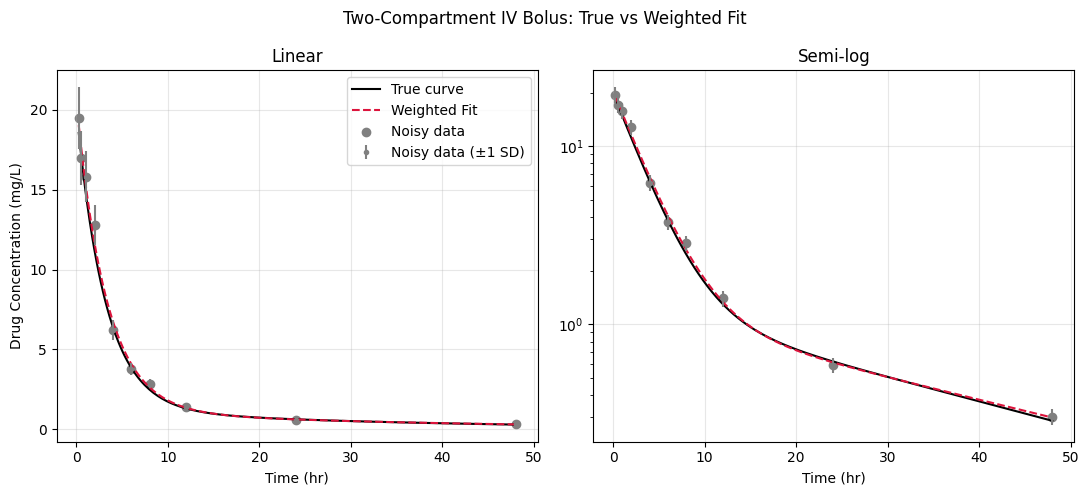

In [47]:
t_smooth = np.linspace(t_samples.min(), t_samples.max(), 200)

_, _, C_true_smooth = two_compartment(t_smooth, D_fixed, Vd_fixed, k10_fixed, k12_fixed, k21_fixed)
C_fitted_smooth = fit_func(t_smooth, param[0], param[1], param[2], param[3])

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Two-Compartment IV Bolus: True vs Weighted Fit')

axs[0].plot(t_smooth, C_true_smooth, color='black', label='True curve')
axs[0].plot(t_smooth, C_fitted_smooth, color='crimson', linestyle='--', label='Weighted Fit')
axs[0].scatter(t_samples, C_noisy, label='Noisy data', color='gray')
axs[0].errorbar(t_samples, C_noisy, yerr=sigma, fmt='o', color='gray', markersize=3, capsize=0, label='Noisy data (±1 SD)')

axs[1].plot(t_smooth, C_true_smooth, color='black', label='True curve')
axs[1].plot(t_smooth, C_fitted_smooth, color='crimson', linestyle='--', label='Weighted Fit')
axs[1].scatter(t_samples, C_noisy, label='Noisy data', color='gray')
axs[1].errorbar(t_samples, C_noisy, yerr=sigma, fmt='o', color='gray', markersize=3, capsize=0, label='Noisy data (±1 SD)')

axs[0].set_yscale('linear')
axs[0].set_title('Linear')
axs[0].set_ylabel('Drug Concentration (mg/L)')
axs[0].legend()

axs[1].set_yscale('log')
axs[1].set_title('Semi-log')

for ax in fig.get_axes():
  ax.set(xlabel='Time (hr)')
  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()